In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [3]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-05'

In [4]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
color_sequence = ["#3f90da","#ffa90e","#bd1f01","#94a4a2","#832db6","#a96b59","#e76300","#b9ac70","#717581","#92dadd"]
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_haa'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$',
               'color' : color_sequence[0]}
}


selection = {
    'nocuts' : "All events"
}

process_infos = ["/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json",
                 "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"]

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [5]:
def error_boxes (ax,x,y,x_err,y_err,fc='lightgrey',ec='None',alpha=0.5, hatch=None):

    # Create list for all the error patches
    errorboxes = []

    # Loop over data points; create box from errors at each point
    for xc,yc,xe,ye in zip(x,y,x_err.T,y_err.T):
        rect = patches.Rectangle((xc-xe,yc-ye),2*xe,2*ye)
        errorboxes.append(rect)

    # Create patch collection with specified colour/alpha
    pc = PatchCollection(errorboxes,facecolor=fc,alpha=alpha,edgecolor=ec, hatch=hatch)

    # Add collection to axes
    ax.add_collection(pc)

In [6]:
process_dicts = []
for inputname in process_infos :
    with open(inputname, 'r') as f :
        process_dicts.append(json.load(f))

In [7]:
from importlib import import_module
import sys
sys.path.insert(1, "../")

In [8]:
# ok now I want to plot b-jets and photons variables
selection = {
    "nocuts" : "All events",
    "lep_channel" : "Photon and $b$-jet sel., $\geq$ 1 lepton",
}
analysis_final = import_module("analysis_final")
variables_dict = analysis_final.histoList

In [9]:
variables_list = [
            'pT_y1', "eta_y1",
            'pT_y2', 'eta_y2',
            'iso_y1', 'iso_y2',
            "HtoYY_pT_y1", "HtoYY_eta_y1",
            "HtoYY_pT_y2", "HtoYY_eta_y2", 
            "HtoYY_iso_y1", "HtoYY_iso_y2",
            "HtoYY_has_higgs_parent_y1", "HtoYY_has_higgs_parent_y2",
            'weight'
]

In [10]:
df = {}
sow = {}

In [11]:
for p in process.keys() :
    df[p] = {}
    print(p)
    variable_list1 = variables_list + ['pT_higgs'] if p=='ttHyy' else variables_list
    for s in selection.keys() :
        if s in list(df[p].keys()) :
            pass
        else :
            print("\t\t"+s)
            df1 = []
            sow[p] = []
            for sample in process[p]['sample_list'] :
                inputfile = os.path.join(basedir, sample+"_"+s+".root")
                # get sum of weights
                f = ROOT.TFile.Open(inputfile)
                sow[p].append(f.Get("SumOfWeights").GetVal())
                f.Close()
                # get sample dict
                for d in process_dicts :
                    if sample in list(d.keys()) :
                        process_dict = d.copy()
                        break
                # get sample
                with uproot.open(inputfile) as f :
                    df1.append(ak.to_dataframe(f['events'].arrays(expressions=variable_list1, library='ak')))
                    df1[-1]["weight"] = df1[-1]["weight"]/sow[p][-1]*process_dict[sample]['crossSection']*process_dict[sample]['kfactor']*process_dict[sample]['matchingEfficiency']
            df[p][s] = pd.concat(df1, copy=True, ignore_index=True)

ttHyy
		nocuts
		lep_channel


In [12]:
process_key = list(process.keys())[0]
process_label = process[process_key]['label']
sel_key = list(selection.keys())[0]
sel_label = selection[sel_key]

In [13]:
df1 = df[process_key][sel_key].copy()

KeyError: ''

In [ ]:
df2 = df1[(df1['HtoYY_has_higgs_parent_y1']==1) & (df1['HtoYY_has_higgs_parent_y2']==1)]

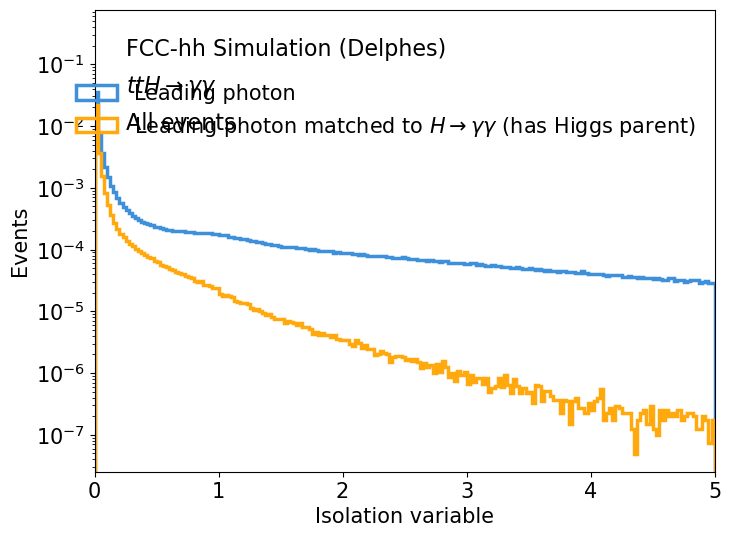

In [72]:
# plot the myy distribution for each category
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

for i, (dd, v, v_label) in enumerate(list(zip([df1, df2], ['iso_y1', 'HtoYY_iso_y1'], ["Leading photon", r"Leading photon matched to $H\rightarrow\gamma\gamma$" + "\n(has Higgs parent)"]))) :
    bin_values, bin_edges, _ = ax.hist(dd[v], weights=dd["weight"],
        bins=200, range=(0,5),
        histtype='step', linewidth=2.5, color=color_sequence[i], label=v_label)
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, sel_label, transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.88))

xlabel = "Isolation variable"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(0,5)
ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*10)
    
plotname = "isolation_variable_leading_photon_nocuts"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [73]:
len(df2[df2["HtoYY_iso_y1"]<0.1])/len(df2)

0.8771755353411572

In [75]:
len(df2[df2["HtoYY_iso_y2"]<0.1])/len(df2)

0.7778880143281331

In [81]:
len(df1[np.abs(df1["iso_y1"])<0.1])/len(df1[df1["iso_y1"]>=0.])

0.640818888737037

In [77]:
0.6456387289539975*0.44307866794295364

0.2860687479973189

In [78]:
0.8771755353411572*0.7778880143281331

0.68234433540375

In [82]:
len(df1[np.abs(df1["iso_y2"])<0.1])/len(df1[df1["iso_y2"]>=0.])

0.37736779441898016

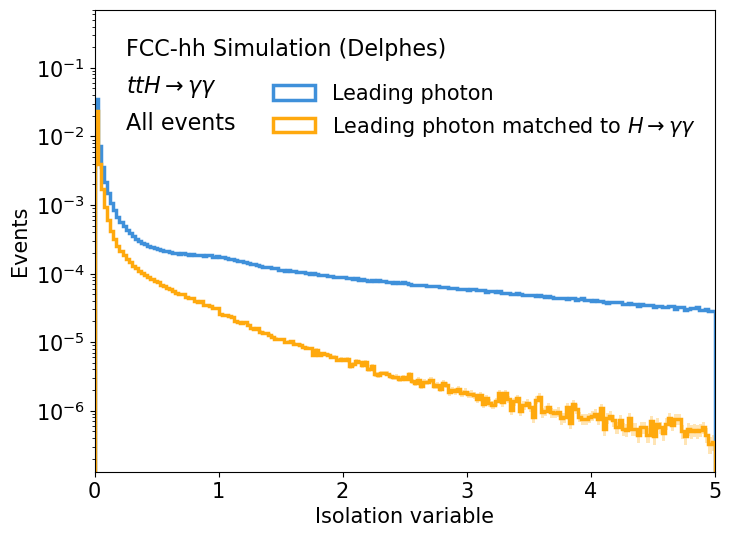

In [41]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

for i, (dd, v, v_label) in enumerate(list(zip([df1, df2], ['iso_y1', 'HtoYY_iso_y1'], ["Leading photon", r"Leading photon matched to $H\rightarrow\gamma\gamma$ (has Higgs parent)"]))) :
    bin_values, bin_edges, _ = ax.hist(df1[v], weights=df1["weight"],
        bins=200, range=(0,5),
        histtype='step', linewidth=2.5, color=color_sequence[i], label=v_label)

    # uncertainty
    x = 0.5*(bin_edges[1:]+bin_edges[:-1])
    xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
    bin_unc, _ = np.histogram(df1[v], weights=df1["weight"]**2, bins=200, range=(0,5))
    bin_unc = np.sqrt(bin_unc)
    error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[i])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, sel_label, transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.88))

xlabel = "Isolation variable"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(0,5)
ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*10)
    
plotname = "isolation_variable_subleading_photon_nocuts"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [43]:
sel_key = list(selection.keys())[1]
sel_label = selection[sel_key]

In [44]:
df1 = df[process_key][sel_key].copy()

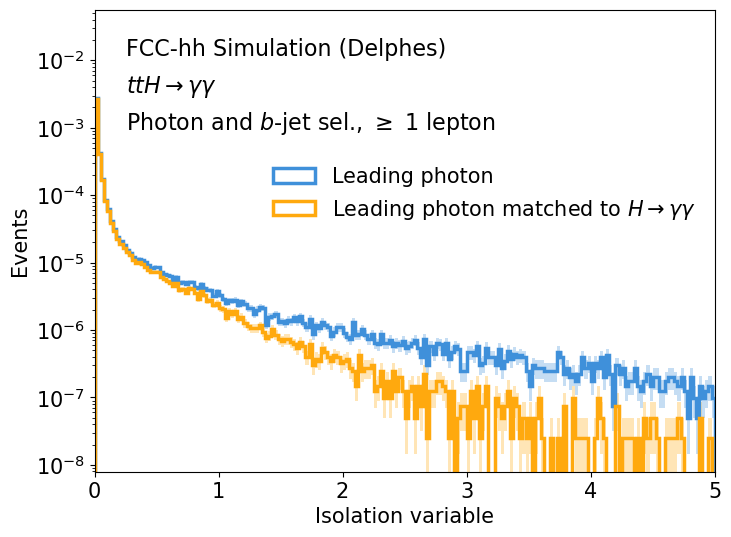

In [48]:
# plot the myy distribution for each category
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

for i, (v, v_label) in enumerate(list(zip(['iso_y1', 'HtoYY_iso_y1'], ["Leading photon", r"Leading photon matched to $H\rightarrow\gamma\gamma$"]))) :
    bin_values, bin_edges, _ = ax.hist(df1[v], weights=df1["weight"],
        bins=200, range=(0,5),
        histtype='step', linewidth=2.5, color=color_sequence[i], label=v_label)

    # uncertainty
    x = 0.5*(bin_edges[1:]+bin_edges[:-1])
    xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
    bin_unc, _ = np.histogram(df1[v], weights=df1["weight"]**2, bins=200, range=(0,5))
    bin_unc = np.sqrt(bin_unc)
    error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[i])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, sel_label, transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.70))

xlabel = "Isolation variable"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(0,5)
ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*10)
    
plotname = "isolation_variable_leading_photon_lep_channel"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

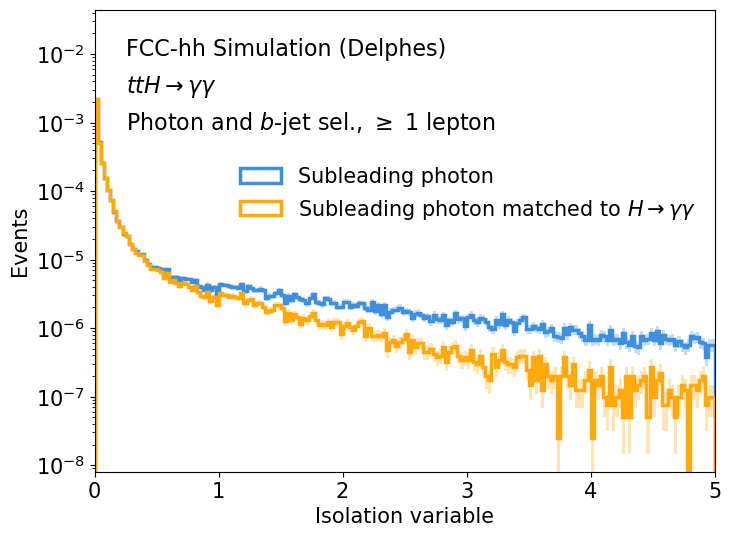

In [49]:
# plot the myy distribution for each category
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

for i, (v, v_label) in enumerate(list(zip(['iso_y2', 'HtoYY_iso_y2'], ["Subleading photon", r"Subleading photon matched to $H\rightarrow\gamma\gamma$"]))) :
    bin_values, bin_edges, _ = ax.hist(df1[v], weights=df1["weight"],
        bins=200, range=(0,5),
        histtype='step', linewidth=2.5, color=color_sequence[i], label=v_label)

    # uncertainty
    x = 0.5*(bin_edges[1:]+bin_edges[:-1])
    xerr = 0.5*(bin_edges[1:]-bin_edges[:-1])
    bin_unc, _ = np.histogram(df1[v], weights=df1["weight"]**2, bins=200, range=(0,5))
    bin_unc = np.sqrt(bin_unc)
    error_boxes(ax, x, bin_values, xerr, bin_unc, alpha=0.3, fc=color_sequence[i])
    
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.82, process_label, transform=ax.transAxes, fontsize=16)
ax.text(0.05, 0.74, sel_label, transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15, bbox_to_anchor=(1.00, 0.70))

xlabel = "Isolation variable"
ax.set_xlabel(xlabel)
ax.set_ylabel(r'Events')

ax.set_xlim(0,5)
ax.set_yscale("log")
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*10)
    
plotname = "isolation_variable_subleading_photon_lep_channel"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [56]:
# get efficiency
df_all = df[process_key]['nocuts'][(df[process_key]['nocuts']['HtoYY_pT_y1']!=-999.) & (df[process_key]['nocuts']['HtoYY_pT_y2']!=-999.)]
df_all_y1 = df_all[['HtoYY_iso_y1', "HtoYY_pT_y1", "weight"]]
df_all_y2 = df_all[['HtoYY_iso_y2', "HtoYY_pT_y1", "weight"]]
df_all_y1 = df_all_y1.rename(columns={'HtoYY_iso_y1' : 'HtoYY_iso_y', "HtoYY_pT_y1" : "HtoYY_pT_y"})
df_all_y2 = df_all_y2.rename(columns={'HtoYY_iso_y2' : 'HtoYY_iso_y', "HtoYY_pT_y1" : "HtoYY_pT_y"})
df_all_y = pd.concat([df_all_y1, df_all_y2], copy=True, ignore_index=True)

In [57]:
len(df_all_y[df_all_y['HtoYY_iso_y']<0.1])/len(df_all_y)

0.8078047033320553

In [60]:
# get efficiency
df_all = df[process_key]['nocuts'].copy()
df_all_y1 = df_all[['iso_y1', "weight"]]
df_all_y2 = df_all[['iso_y2', "weight"]]
df_all_y1 = df_all_y1.rename(columns={'iso_y1' : 'iso_y'})
df_all_y2 = df_all_y2.rename(columns={'iso_y2' : 'iso_y'})
df_all_y = pd.concat([df_all_y1, df_all_y2], copy=True, ignore_index=True)

In [61]:
len(df_all_y[df_all_y['iso_y']<0.1])/len(df_all_y)

0.5443586984484756